<a href="https://colab.research.google.com/github/siddharth-0309/predictive-maintenance-cmapss/blob/main/predictive_maintenance_cmapss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/Manufacturing dataset (NASA CMAPSS)/'
print(os.listdir(path))

Mounted at /content/drive
['RUL_FD002.csv', 'test_FD001.csv', 'RUL_FD004.csv', 'RUL_FD001.csv', 'RUL_FD003.csv', 'test_FD002.csv', 'train_FD003.csv', 'test_FD004.csv', 'train_FD002.csv', 'test_FD003.csv', 'train_FD004.csv', 'train_FD001.csv']


# **RUL = Remaining Useful Life***

In [11]:
path = '/content/drive/MyDrive/Manufacturing dataset (NASA CMAPSS)/'

train = pd.read_csv(path + 'train_FD001.csv')
print(train.shape)
print(train.columns.tolist())
train.head()

(20631, 26)
['unit_nr', 'time_cycles', 'setting1', 'setting2', 'setting3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']


,unit_nr,time_cycles,setting1,setting2,setting3,T2,T24,T30,T50,P2,...,Phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [12]:
# Get the maximum cycle for each engine (when it failed)
max_cycles = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']

# Merge with train data
train = train.merge(max_cycles, on='unit_nr', how='left')

# Calculate RUL
train['RUL'] = train['max_cycle'] - train['time_cycles']

# Drop max_cycle column as it's no longer needed
train.drop('max_cycle', axis=1, inplace=True)

print(train[['unit_nr', 'time_cycles', 'RUL']].head(10))
print(train[train['unit_nr']==1].tail())  # Check last cycles of engine 1 - RUL should be 0 on the last row

   unit_nr  time_cycles  RUL
0        1            1  191
1        1            2  190
2        1            3  189
3        1            4  188
4        1            5  187
5        1            6  186
6        1            7  185
7        1            8  184
8        1            9  183
9        1           10  182
     unit_nr  time_cycles  setting1  setting2  setting3      T2     T24  \
187        1          188   -0.0067    0.0003     100.0  518.67  643.75   
188        1          189   -0.0006    0.0002     100.0  518.67  644.18   
189        1          190   -0.0027    0.0001     100.0  518.67  643.64   
190        1          191   -0.0000   -0.0004     100.0  518.67  643.34   
191        1          192    0.0009   -0.0000     100.0  518.67  643.54   

         T30      T50     P2  ...      NRf      NRc     BPR  farB  htBleed  \
187  1602.38  1422.78  14.62  ...  2388.23  8117.69  8.5207  0.03      396   
188  1596.17  1428.01  14.62  ...  2388.33  8117.51  8.5183  0.03      395

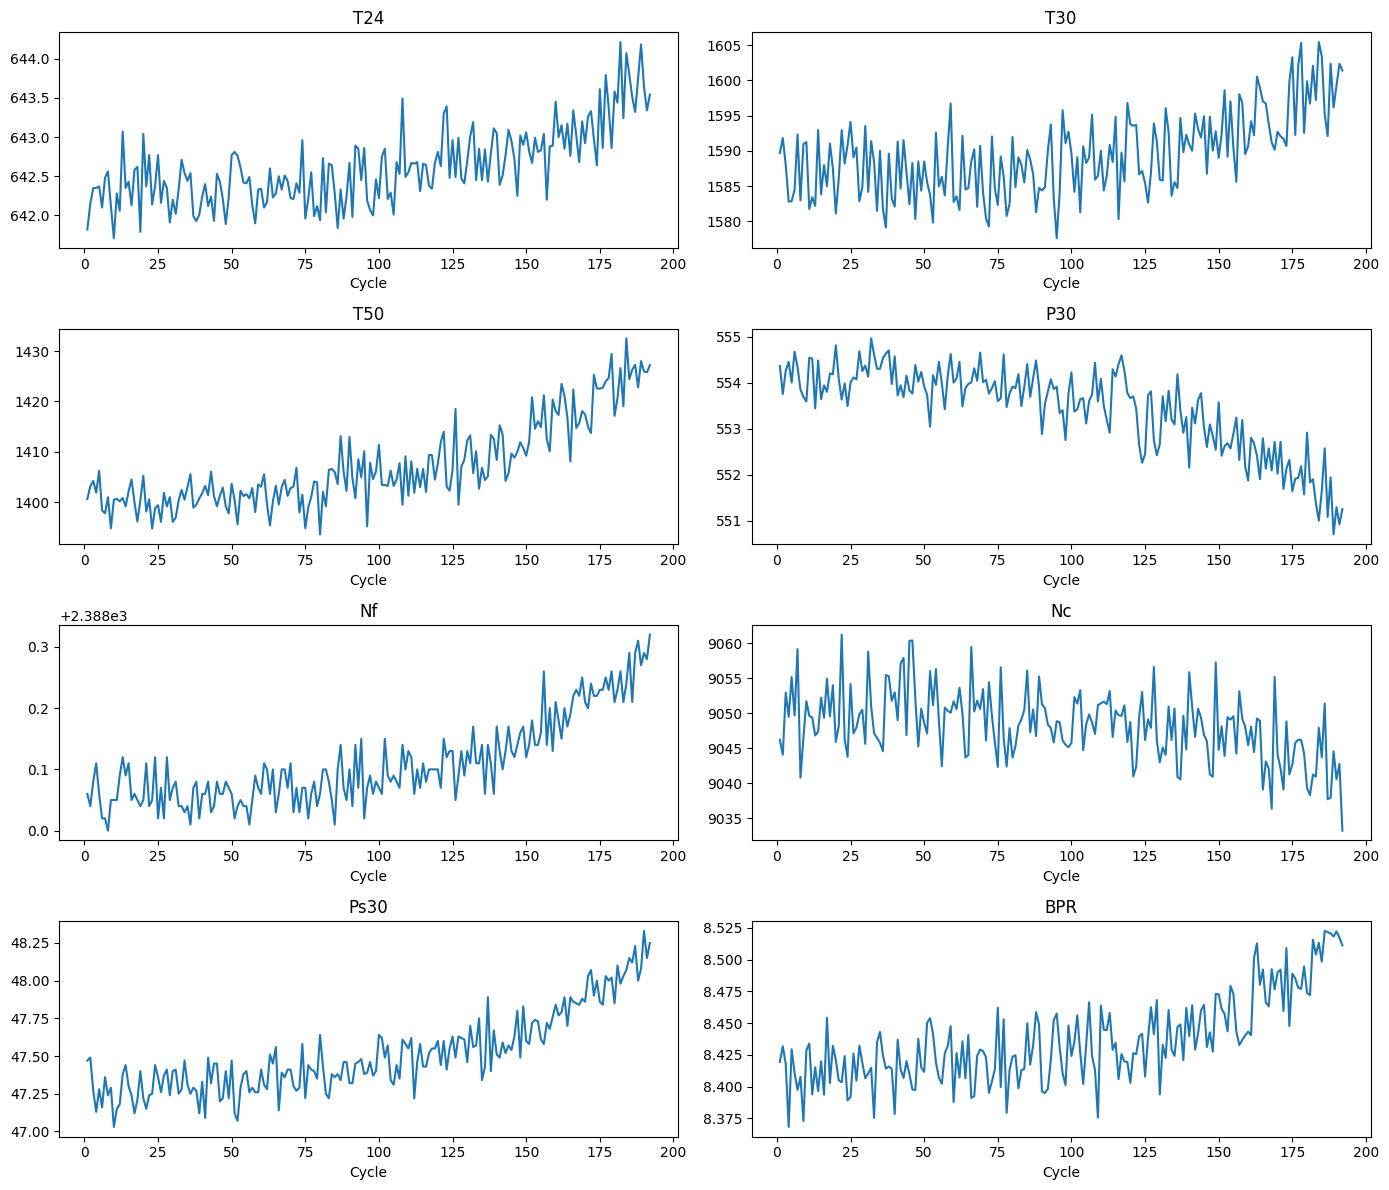

In [13]:
import matplotlib.pyplot as plt

# Isolate data for Engine 1
engine_1 = train[train['unit_nr'] == 1]

# Plot some important sensors against RUL
sensors_to_check = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'BPR']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_check):
    axes[i].plot(engine_1['time_cycles'], engine_1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

In [14]:
# Check the standard deviation of each sensor — if it's very close to 0, it means it's flat
train.std(numeric_only=True).sort_values()

,0
setting3,0.000000e+00
Nf_dmd,0.000000e+00
PCNfR_dmd,0.000000e+00
farB,1.556432e-14
epr,4.660829e-13
P2,3.394700e-12
T2,6.537152e-11
setting2,2.930621e-04
P15,1.388985e-03
setting1,2.187313e-03


In [15]:
flat_sensors = ['setting3', 'Nf_dmd', 'PCNfR_dmd', 'farB', 'epr', 'P2', 'T2', 'setting1', 'setting2', 'P15']

train_clean = train.drop(columns=flat_sensors)
print(train_clean.shape)
print(train_clean.columns.tolist())

(20631, 17)
['unit_nr', 'time_cycles', 'T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32', 'RUL']


In [16]:
sensors = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']

# Rolling average (window = 5 cycles) — within each engine
for sensor in sensors:
    train_clean[f'{sensor}_rolling_mean'] = (
        train_clean.groupby('unit_nr')[sensor]
        .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    )

print(train_clean.shape)
train_clean[train_clean['unit_nr']==1][['time_cycles', 'T24', 'T24_rolling_mean']].head(10)

(20631, 31)


,time_cycles,T24,T24_rolling_mean
0,1,641.82,641.820000
1,2,642.15,641.985000
2,3,642.35,642.106667
3,4,642.35,642.167500
4,5,642.37,642.208000
5,6,642.10,642.264000
6,7,642.48,642.330000
7,8,642.56,642.372000
8,9,642.12,642.326000
9,10,641.71,642.194000


In [17]:
for sensor in sensors:
    train_clean[f'{sensor}_rate_of_change'] = (
        train_clean.groupby('unit_nr')[sensor]
        .transform(lambda x: x.diff().fillna(0))
    )

print(train_clean.shape)
train_clean[train_clean['unit_nr']==1][['time_cycles', 'T24', 'T24_rate_of_change']].head(10)

(20631, 45)


,time_cycles,T24,T24_rate_of_change
0,1,641.82,0.00
1,2,642.15,0.33
2,3,642.35,0.20
3,4,642.35,0.00
4,5,642.37,0.02
5,6,642.10,-0.27
6,7,642.48,0.38
7,8,642.56,0.08
8,9,642.12,-0.44
9,10,641.71,-0.41


In [18]:
import numpy as np

# Get unique engine IDs
unique_engines = train_clean['unit_nr'].unique()

# Shuffle them and split (80% train engines, 20% validation engines)
np.random.seed(42)
shuffled_engines = np.random.permutation(unique_engines)

split_point = int(0.8 * len(shuffled_engines))
train_engines = shuffled_engines[:split_point]
val_engines = shuffled_engines[split_point:]

# Now split the actual data based on these engine IDs
train_data = train_clean[train_clean['unit_nr'].isin(train_engines)]
val_data = train_clean[train_clean['unit_nr'].isin(val_engines)]

print(f"Train engines: {len(train_engines)}, Train rows: {train_data.shape[0]}")
print(f"Val engines: {len(val_engines)}, Val rows: {val_data.shape[0]}")

Train engines: 80, Train rows: 16340
Val engines: 20, Val rows: 4291


In [19]:
# ============================================
# STEP 1: Prepare X, y (with vs without capping)
# ============================================
drop_cols = ['unit_nr', 'time_cycles', 'RUL']

X_train = train_data.drop(columns=drop_cols)
y_train_raw = train_data['RUL']

X_val = val_data.drop(columns=drop_cols)
y_val_raw = val_data['RUL']

# Capped version (X remains the same, only y changes)
y_train_capped = y_train_raw.clip(upper=125)
y_val_capped = y_val_raw.clip(upper=125)

print("Raw y_train range:", y_train_raw.min(), "-", y_train_raw.max())
print("Capped y_train range:", y_train_capped.min(), "-", y_train_capped.max())

Raw y_train range: 0 - 361
Capped y_train range: 0 - 125


In [20]:
# ============================================
# STEP 2: Install LightGBM (if not already installed)
# ============================================
!pip install lightgbm -q

In [21]:
# ============================================
# STEP 3: Train + Evaluate function
# ============================================
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

def train_and_eval(X_train, y_train, X_val, y_val, label):
    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"[{label}] MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    return model, preds

print("=== WITHOUT CAPPING ===")
model_raw, preds_raw = train_and_eval(X_train, y_train_raw, X_val, y_val_raw, "Raw RUL")

print("\n=== WITH CAPPING (125) ===")
model_capped, preds_capped = train_and_eval(X_train, y_train_capped, X_val, y_val_capped, "Capped RUL")

=== WITHOUT CAPPING ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8663
[LightGBM] [Info] Number of data points in the train set: 16340, number of used features: 42
[LightGBM] [Info] Start training from score 106.659119
[Raw RUL] MAE: 32.53, RMSE: 44.91

=== WITH CAPPING (125) ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8663
[LightGBM] [Info] Number of data points in the train set: 16340, number of used features: 42
[LightGBM] [Info] Start training from score 86.444308
[Capped RUL] MAE: 13.99, RMSE: 20.22


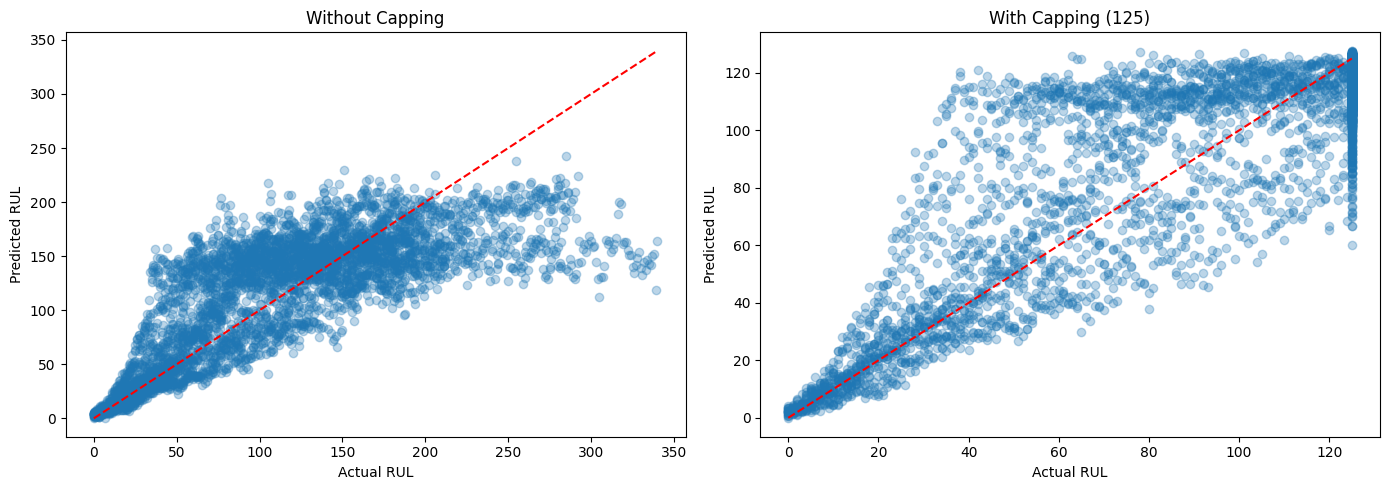

In [22]:
# ============================================
# STEP 4: Visual comparison
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val_raw, preds_raw, alpha=0.3)
axes[0].plot([0, y_val_raw.max()], [0, y_val_raw.max()], 'r--')
axes[0].set_title('Without Capping')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')

axes[1].scatter(y_val_capped, preds_capped, alpha=0.3)
axes[1].plot([0, 125], [0, 125], 'r--')
axes[1].set_title('With Capping (125)')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')

plt.tight_layout()
plt.show()

              feature  importance
23   NRc_rolling_mean         596
19    Nc_rolling_mean         500
24   BPR_rolling_mean         368
27   W32_rolling_mean         358
14   T24_rolling_mean         352
20  Ps30_rolling_mean         333
16   T50_rolling_mean         320
15   T30_rolling_mean         314
26   W31_rolling_mean         310
22   NRf_rolling_mean         292
17   P30_rolling_mean         288
21   Phi_rolling_mean         278
18    Nf_rolling_mean         267
9                 NRc         224
7                 Phi         203


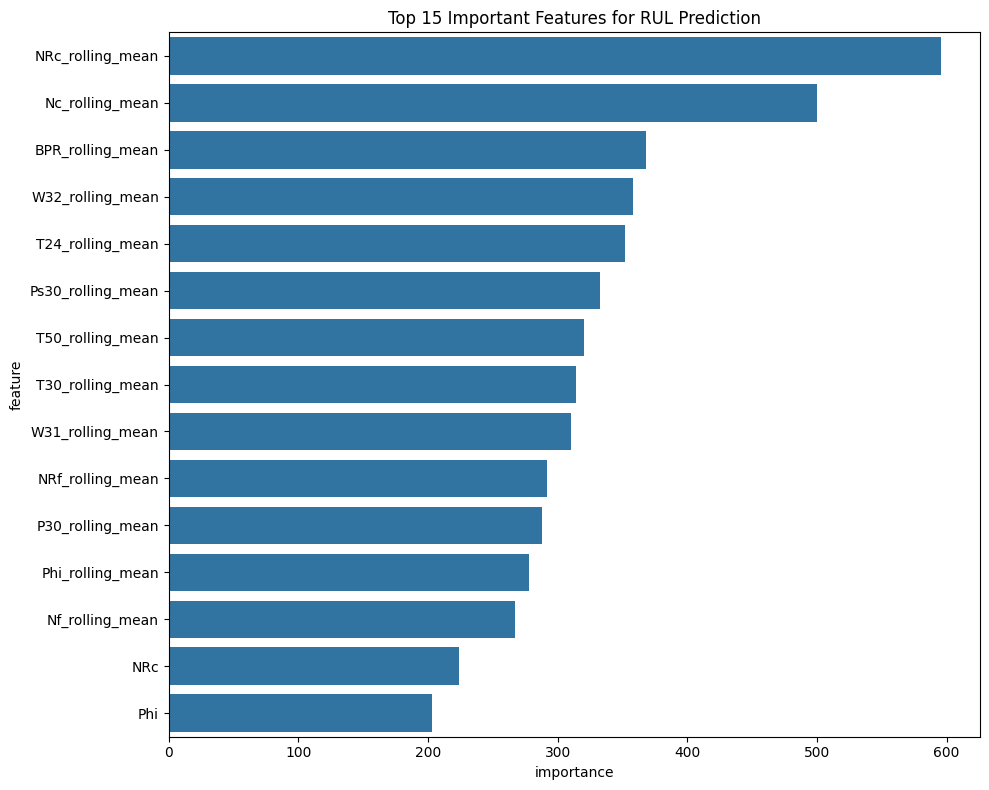

In [23]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_capped.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Important Features for RUL Prediction')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
path = '/content/drive/MyDrive/Manufacturing dataset (NASA CMAPSS)/'
# ============================================
# STEP 6: Load Test Set + Same Preprocessing
# ============================================
test = pd.read_csv(path + 'test_FD001.csv')
true_rul = pd.read_csv(path + 'RUL_FD001.csv', header=None, names=['RUL'])

print(test.shape)
print(test.columns.tolist())
print(true_rul.shape)
true_rul.head()

(13096, 26)
['unit_nr', 'time_cycles', 'setting1', 'setting2', 'setting3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'Phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
(101, 1)


,,,,,,,,,,,,,,,,,,,,,,,,,RUL
unit_nr,time_cycles,setting1,setting2,setting3,T2,T24,T30,T50,P2,P15,P30,Nf,Nc,epr,Ps30,Phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# ============================================
# STEP 6: Test set preprocessing (same as train)
# ============================================
test = pd.read_csv(path + 'test_FD001.csv')
# Load true_rul correctly, ensuring it's a single column of integers
true_rul = pd.read_csv(path + 'RUL_FD001.csv', usecols=[0])
true_rul.columns = ['RUL']
true_rul = true_rul.dropna().reset_index(drop=True)

# Drop same flat sensors
test_clean = test.drop(columns=flat_sensors)

# Same rolling mean
for sensor in sensors:
    test_clean[f'{sensor}_rolling_mean'] = (
        test_clean.groupby('unit_nr')[sensor]
        .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    )

# Same rate of change
for sensor in sensors:
    test_clean[f'{sensor}_rate_of_change'] = (
        test_clean.groupby('unit_nr')[sensor]
        .transform(lambda x: x.diff().fillna(0))
    )

print(test_clean.shape)

(13096, 44)


In [26]:
true_rul = pd.read_csv(path + 'RUL_FD001.csv', usecols=[0])
true_rul.columns = ['RUL']
true_rul = true_rul.dropna().reset_index(drop=True)
print(true_rul.shape)
print(true_rul.head())

(100, 1)
   RUL
0  112
1   98
2   69
3   82
4   91


In [27]:
# ============================================
# STEP 7: Merge last cycle of each engine + actual RUL
# ============================================
test_last = test_clean.groupby('unit_nr').last().reset_index()
print(test_last.shape)   # Should be (100, 44)

test_last['actual_RUL'] = true_rul['RUL'].values
test_last[['unit_nr', 'time_cycles', 'actual_RUL']].head(10)

(100, 44)


,unit_nr,time_cycles,actual_RUL
0,1,31,112
1,2,49,98
2,3,126,69
3,4,106,82
4,5,98,91
5,6,105,93
6,7,160,91
7,8,166,95
8,9,55,111
9,10,192,96


In [28]:
# ============================================
# STEP 8: Predict and evaluate
# ============================================
X_test = test_last.drop(columns=['unit_nr', 'time_cycles', 'actual_RUL'])
y_test_actual = test_last['actual_RUL'].clip(upper=125)   # For a fair comparison against the capped model

test_preds = model_capped.predict(X_test)

mae_test = mean_absolute_error(y_test_actual, test_preds)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, test_preds))
print(f"TEST SET -> MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")

TEST SET -> MAE: 12.94, RMSE: 17.95


In [29]:
import joblib

# Save the model
joblib.dump(model_capped, 'rul_model.pkl')

# Save feature columns (Flask needs to know which columns are required, and in what order)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Saved!")

Saved!


In [30]:
# Save the processed test data (for engine dropdown + charts)
test_clean.to_csv('test_last.csv', index=False)

from google.colab import files
files.download('test_last.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **----------------------------------------------**